# Heart Disease — Model Training & Evaluation

Sections:
1. Load and stratified split
2. Candidate model specs
3. GridSearchCV (LR + RF) with 5-fold stratified CV
4. Side-by-side test metrics
5. Confusion matrix & ROC curve for the selected model
6. Persist winning pipeline + metrics.json

In [1]:
import sys, json
from pathlib import Path
import joblib
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_validate, train_test_split,
)
from src.data_loader import load_clean, split_features_target
from src.preprocess import build_pipeline
from src.train import get_model_specs, CV_SCORERS
from src.evaluate import (
    compute_metrics, cv_summary, plot_confusion_matrix, plot_roc_curve,
)
from IPython.display import Image, display

## 1. Load and stratified split

In [2]:
df = load_clean()
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42,
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (242, 13) | Test: (61, 13)


## 2. Candidate model specs

In [3]:
for name, spec in get_model_specs().items():
    print(f'{name:>20s} : {spec["param_grid"]}')

 logistic_regression : {'model__C': [0.01, 0.1, 1.0, 10.0], 'model__penalty': ['l1', 'l2']}
       random_forest : {'model__n_estimators': [100, 200], 'model__max_depth': [None, 5, 10], 'model__min_samples_split': [2, 5]}


## 3. GridSearchCV (5-fold) for both models

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []
for name, spec in get_model_specs().items():
    pipe = build_pipeline(spec['estimator'])
    grid = GridSearchCV(pipe, spec['param_grid'], cv=cv,
                        scoring='roc_auc', n_jobs=-1, refit=True)
    grid.fit(X_train, y_train)
    cv_res = cross_validate(grid.best_estimator_, X_train, y_train,
                            cv=cv, scoring=CV_SCORERS, n_jobs=-1)
    cv_metrics = cv_summary(cv_res)
    y_pred  = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1]
    test_metrics = {f'test_{k}': v for k, v
                    in compute_metrics(y_test, y_pred, y_proba).items()}
    print(f'{name:>20s} | best={grid.best_params_} '
          f'| CV ROC-AUC={cv_metrics["cv_roc_auc_mean"]:.4f}')
    results.append({'name': name, 'best_params': grid.best_params_,
                    'estimator': grid.best_estimator_,
                    'cv_metrics': cv_metrics,
                    'test_metrics': test_metrics})

 logistic_regression | best={'model__C': 1.0, 'model__penalty': 'l1'} | CV ROC-AUC=0.9070


       random_forest | best={'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100} | CV ROC-AUC=0.8984


## 4. Side-by-side test metrics

In [5]:
rows = []
for r in results:
    row = {'model': r['name']}
    row.update({k.replace('test_', ''): round(v, 4)
                for k, v in r['test_metrics'].items()})
    rows.append(row)
pd.DataFrame(rows).set_index('model')

,accuracy,precision,recall,f1,roc_auc
model,,,,,
logistic_regression,0.8689,0.8333,0.8929,0.8621,0.9589
random_forest,0.8852,0.8387,0.9286,0.8814,0.9545


## 5. Plots for the selected model (highest mean CV ROC-AUC)

Selected model: logistic_regression


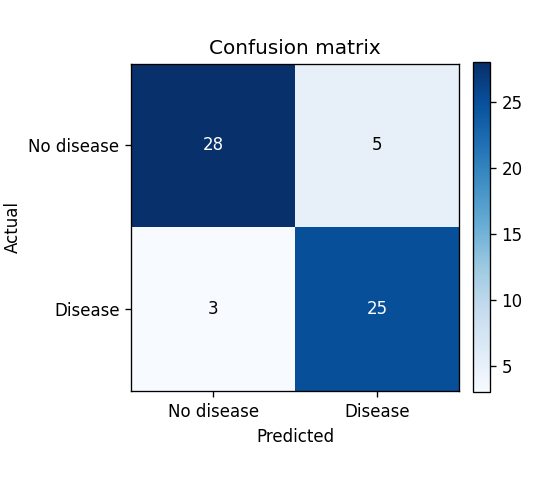

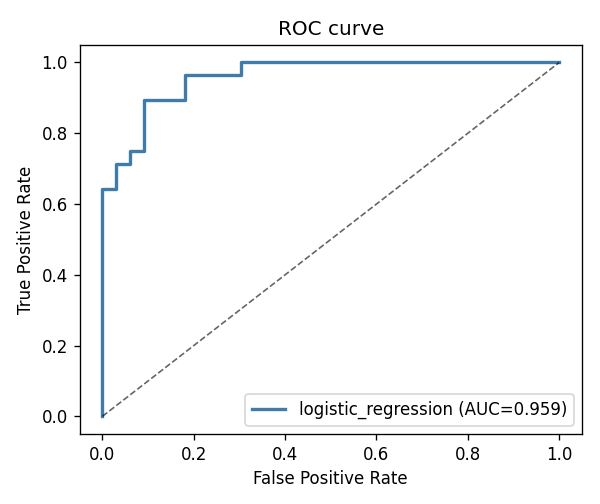

In [6]:
ARTIFACTS = ROOT / 'reports' / 'figures'
ARTIFACTS.mkdir(parents=True, exist_ok=True)
best = max(results, key=lambda r: r['cv_metrics']['cv_roc_auc_mean'])
print('Selected model:', best['name'])
y_pred  = best['estimator'].predict(X_test)
y_proba = best['estimator'].predict_proba(X_test)[:, 1]
cm_path  = plot_confusion_matrix(y_test, y_pred,
                                 ARTIFACTS / f"cm_{best['name']}.png")
roc_path = plot_roc_curve(y_test, y_proba,
                          ARTIFACTS / f"roc_{best['name']}.png",
                          label=best['name'])
display(Image(filename=str(cm_path)))
display(Image(filename=str(roc_path)))

## 6. Persist winning pipeline + metrics.json

In [7]:
MODELS_DIR = ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best['estimator'], MODELS_DIR / 'model.pkl')
report = {
    'selected_model': best['name'],
    'best_params':    best['best_params'],
    'cv_metrics':     best['cv_metrics'],
    'test_metrics':   best['test_metrics'],
}
print(json.dumps(report, indent=2, default=str))

{
  "selected_model": "logistic_regression",
  "best_params": {
    "model__C": 1.0,
    "model__penalty": "l1"
  },
  "cv_metrics": {
    "cv_accuracy_mean": 0.8346938775510205,
    "cv_accuracy_std": 0.013281104320181114,
    "cv_precision_mean": 0.853923740510697,
    "cv_precision_std": 0.05968998414741349,
    "cv_recall_mean": 0.7833992094861661,
    "cv_recall_std": 0.06773324399216349,
    "cv_f1_mean": 0.8122561162711438,
    "cv_f1_std": 0.01730453026349792,
    "cv_roc_auc_mean": 0.9070318570318572,
    "cv_roc_auc_std": 0.011448309514397773
  },
  "test_metrics": {
    "test_accuracy": 0.8688524590163934,
    "test_precision": 0.8333333333333334,
    "test_recall": 0.8928571428571429,
    "test_f1": 0.8620689655172413,
    "test_roc_auc": 0.958874458874459
  }
}
